In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/marslinoedward/sms-spam-dataset/spam.csv


### 1. Business Understanding

Email communication has become very important in today’s time, but daily users often face the problem of spam emails. These emails are usually sent for fraud, advertisements, or fake offers.

### 2. Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Download required NLTK resources
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### 3.Load Dataset

In [3]:
data = pd.read_csv("/kaggle/input/datasets/marslinoedward/sms-spam-dataset/spam.csv")


data.head()

,Unnamed: 0,spamORham,Message
0,0,ham,"Go until jurong point, crazy.. Available only ..."
1,1,ham,Ok lar... Joking wif u oni...
2,2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,3,ham,U dun say so early hor... U c already then say...
4,4,ham,"Nah I don't think he goes to usf, he lives aro..."


### 4. Data Understanding

In [4]:

print("Columns:", data.columns)


data = data.drop(columns=['Unnamed: 0'])


data.columns = ['label', 'message']


print("Shape:", data.shape)

print("\nMissing Values:\n", data.isnull().sum())


print("\nDuplicates:", data.duplicated().sum())
data = data.drop_duplicates()


print("\nLabel Distribution:\n", data['label'].value_counts())


Columns: Index(['Unnamed: 0', 'spamORham', 'Message'], dtype='object')
Shape: (5572, 2)

Missing Values:
 label      0
message    0
dtype: int64

Duplicates: 403

Label Distribution:
 label
ham     4516
spam     653
Name: count, dtype: int64


### 5. Exploratory Data Analysis (EDA)

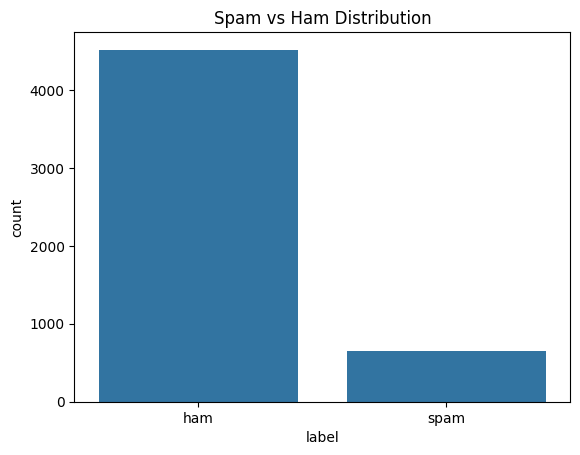

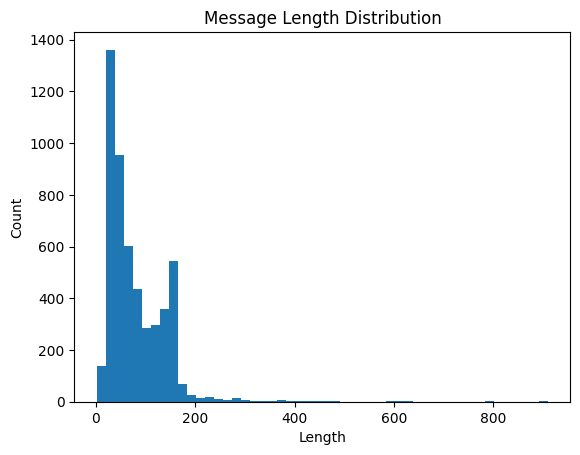

In [5]:

plt.figure()
sns.countplot(x='label', data=data)
plt.title("Spam vs Ham Distribution")
plt.show()


data['length'] = data['message'].apply(len)


plt.figure()
plt.hist(data['length'], bins=50)
plt.title("Message Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()


### 6.Text Preprocessing

In [6]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    
    return " ".join(words)
    
# Apply cleaning
data['clean_message'] = data['message'].apply(clean_text)

data.head()


,label,message,length,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,49,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think goe usf live around though


### 7.Feature Extraction (TF-IDF)

In [7]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(data['clean_message'])
y = data['label']

### 8. Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 9. Model Training

 1. Naive Bayes

In [9]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)


MultinomialNB()

2.Logistic Regression

In [10]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### 10.Model Evaluation

Naive Bayes Accuracy: 0.9700193423597679
Logistic Regression Accuracy: 0.9497098646034816

Naive Bayes Report:
               precision    recall  f1-score   support

         ham       0.97      1.00      0.98       889
        spam       1.00      0.79      0.88       145

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034


Logistic Regression Report:
               precision    recall  f1-score   support

         ham       0.95      0.99      0.97       889
        spam       0.94      0.68      0.79       145

    accuracy                           0.95      1034
   macro avg       0.95      0.84      0.88      1034
weighted avg       0.95      0.95      0.95      1034



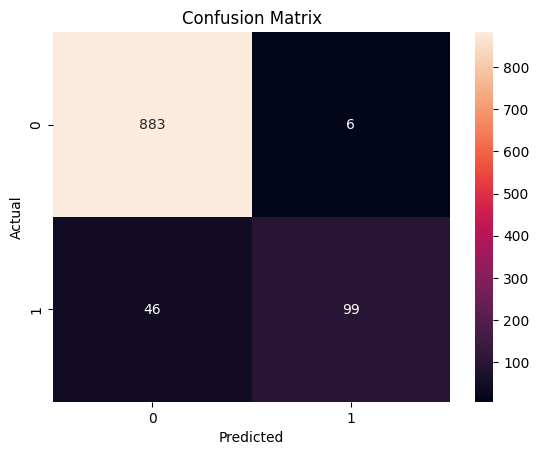

In [11]:

nb_pred = nb_model.predict(X_test)
lr_pred = lr_model.predict(X_test)


print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))


print("\nNaive Bayes Report:\n", classification_report(y_test, nb_pred))
print("\nLogistic Regression Report:\n", classification_report(y_test, lr_pred))

cm = confusion_matrix(y_test, lr_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 11. Prediction System

In [12]:
def predict_message(msg):
    
    msg = clean_text(msg)
    msg = tfidf.transform([msg])
    
    result = lr_model.predict(msg)[0]
    
    return result


# Test
sample_msg = "Congratulations! You have won a free gift card"
print("Message:", sample_msg)
print("Prediction:", predict_message(sample_msg))
sample_msg = "Call now to win free prize"
print("Message:", sample_msg)
print("Prediction:", predict_message(sample_msg))


Message: Congratulations! You have won a free gift card
Prediction: ham
Message: Call now to win free prize
Prediction: spam
